In [8]:
import matplotlib.pyplot as plt
import json
from tqdm import tqdm
from datetime import datetime
from pathlib import Path

DATA_PATH = Path('../raw_data/prebuilt_models')

In [9]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 4188689.5220232783


In [10]:
def parse_power_log(log_values: list[str]) -> list[tuple]:
    """Convert each power log entry to (datetime, power).

    Args:
        log_values: List of timestamp, current and voltage as string.

    Returns:
        Processed log for easy accessing the timestamp and power.
    """
    result = []
    for entry in tqdm(log_values):
        parts = entry.strip().split(",")
        timestamp = datetime.strptime(parts[0], "%Y%m%d-%H:%M:%S.%f")
        voltage = float(parts[1])
        current = float(parts[2])
        result.append((timestamp, voltage * current))
    return result


Model: resnext101_32x8d


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2276409/2276409 [00:37<00:00, 61229.56it/s]


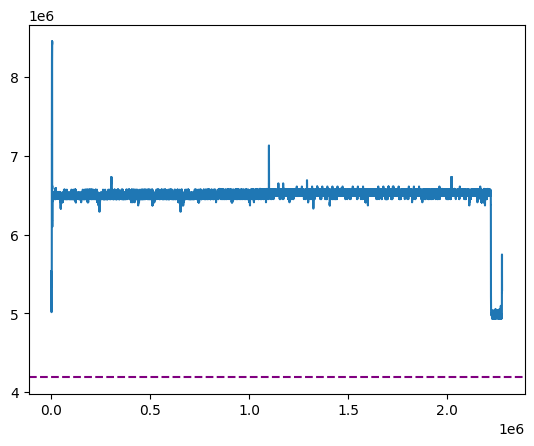

Model: lenet


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46765/46765 [00:00<00:00, 61303.43it/s]


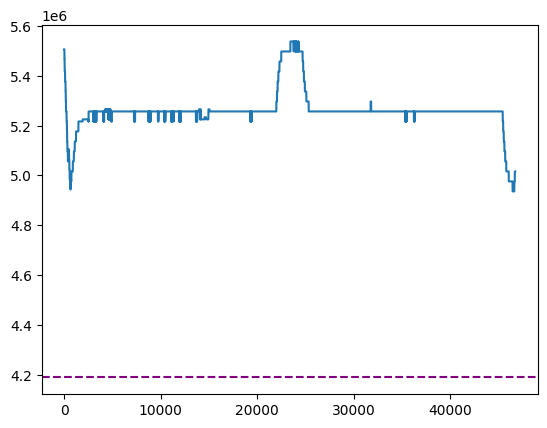

Model: resnet152


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3226486/3226486 [00:42<00:00, 75050.34it/s]


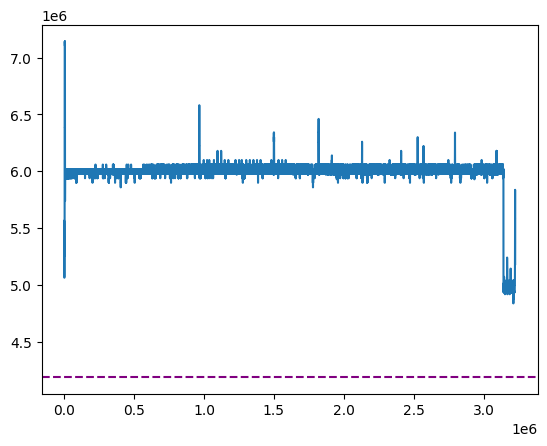

Model: mobilenet_v3_small


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 872763/872763 [00:13<00:00, 62971.97it/s]


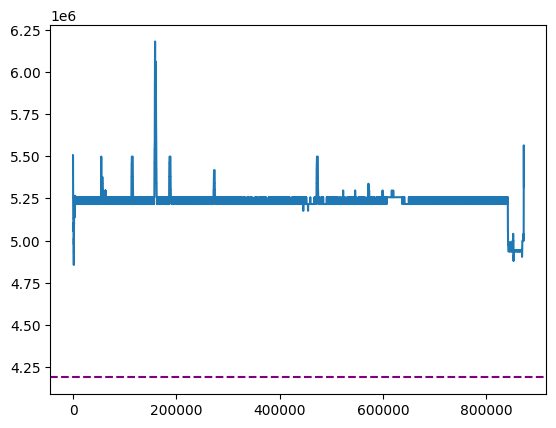

Model: vgg16


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 662099/662099 [00:10<00:00, 61902.36it/s]


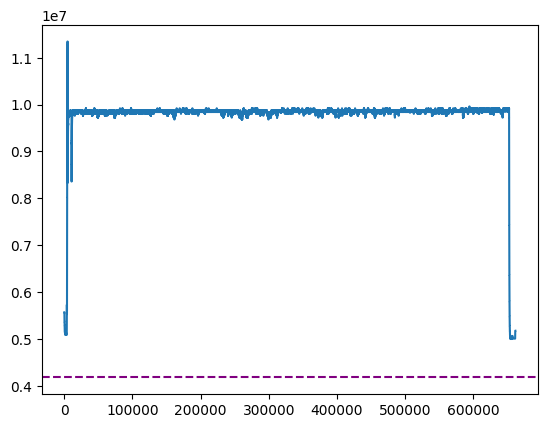

Model: convnext_base


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1915831/1915831 [00:30<00:00, 62391.08it/s]


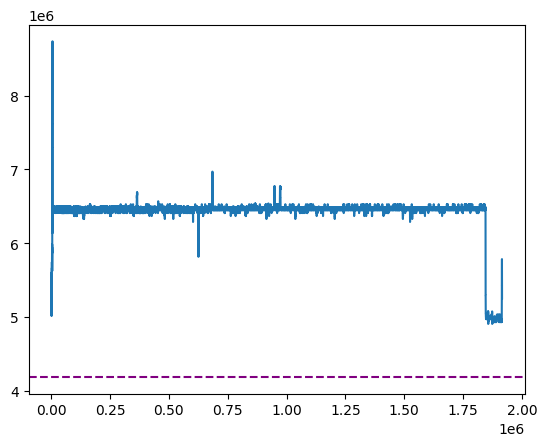

Model: vgg11


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 450189/450189 [00:06<00:00, 64324.08it/s]


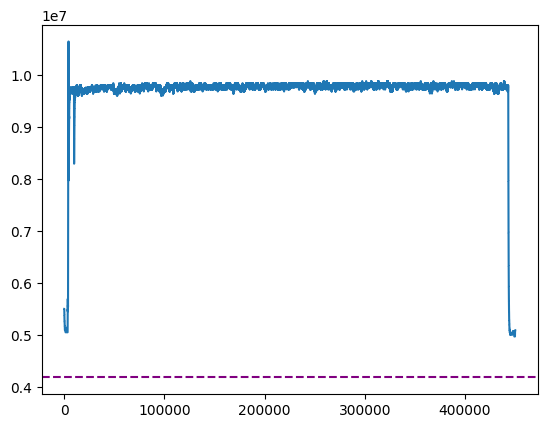

Model: mobilenet_v2


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 923633/923633 [00:15<00:00, 59945.13it/s]


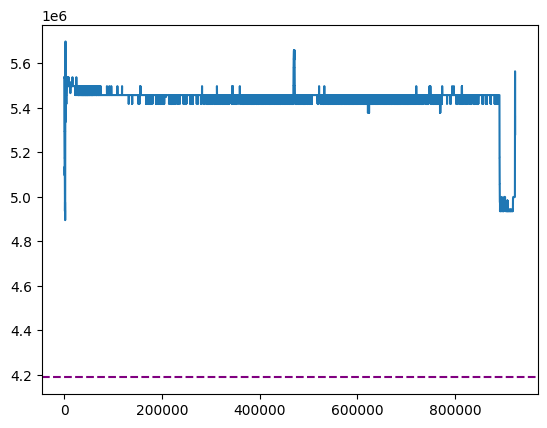

Model: vgg19


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 757837/757837 [00:12<00:00, 61619.66it/s]


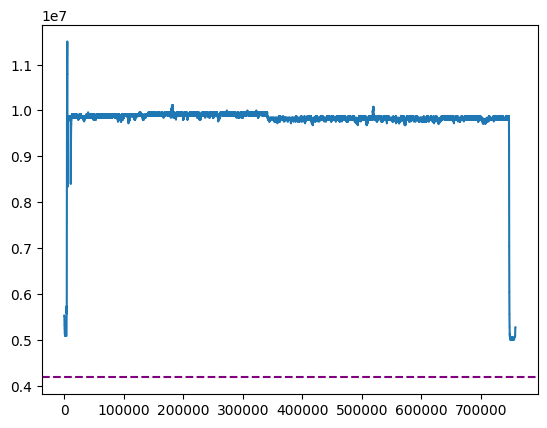

Model: resnet18


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 511693/511693 [00:08<00:00, 61637.70it/s]


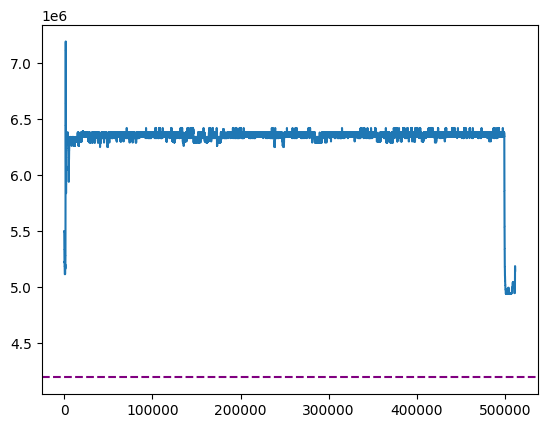

Model: convnext_small


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1762702/1762702 [00:29<00:00, 60293.79it/s]


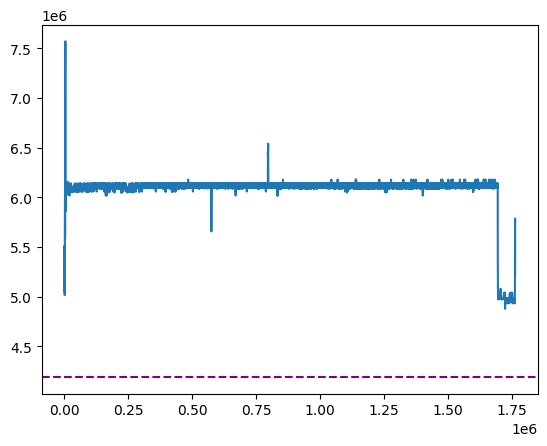

Model: mobilenet_v3_large


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1086947/1086947 [00:18<00:00, 59631.02it/s]


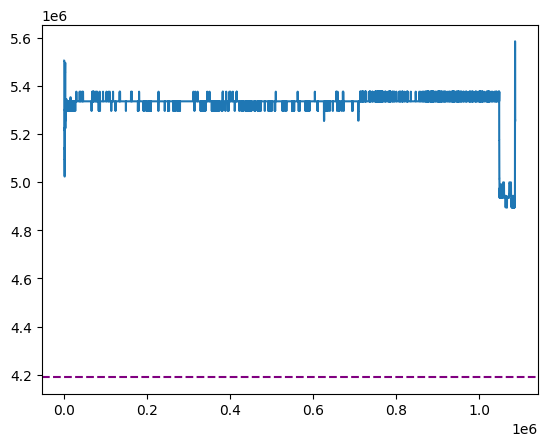

Model: resnext50_32x4d


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1091937/1091937 [00:18<00:00, 60490.41it/s]


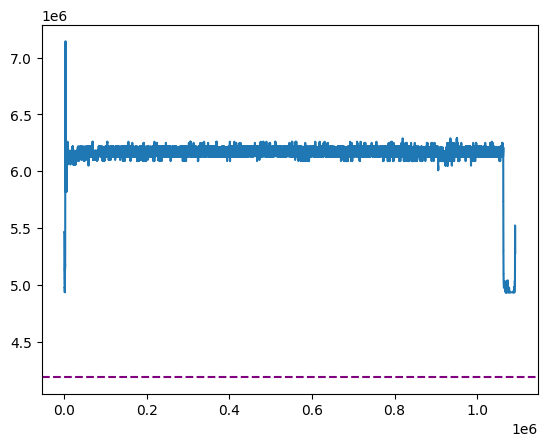

Model: resnet50


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1131004/1131004 [00:19<00:00, 58461.60it/s]


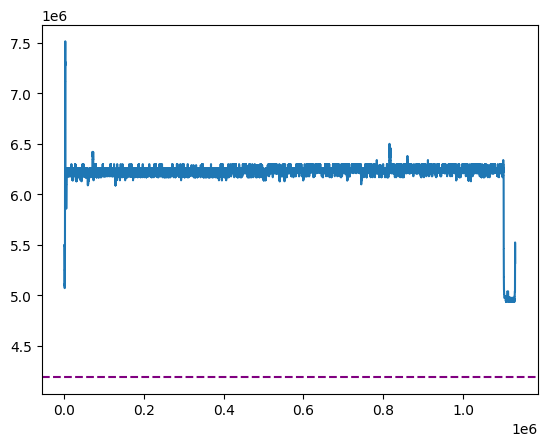

Model: resnet34


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 884559/884559 [00:15<00:00, 57970.33it/s]


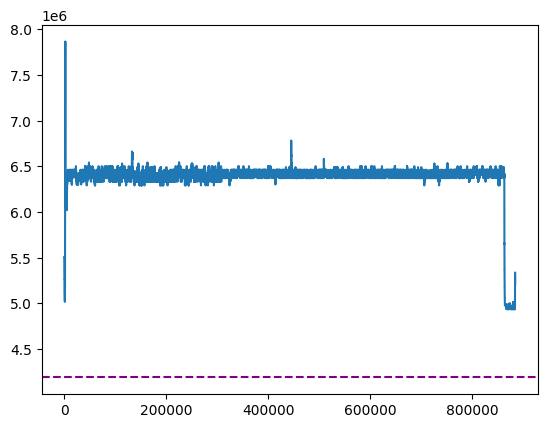

Model: resnext101_64x4d


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2309151/2309151 [00:41<00:00, 56106.17it/s]


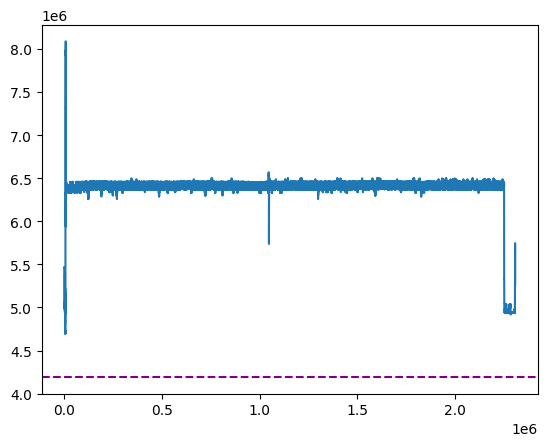

Model: alexnet


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 193674/193674 [00:03<00:00, 54662.53it/s]


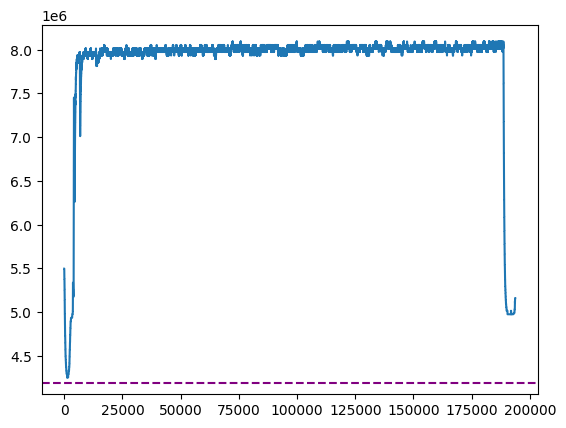

Model: convnext_tiny


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 959800/959800 [00:17<00:00, 56361.35it/s]


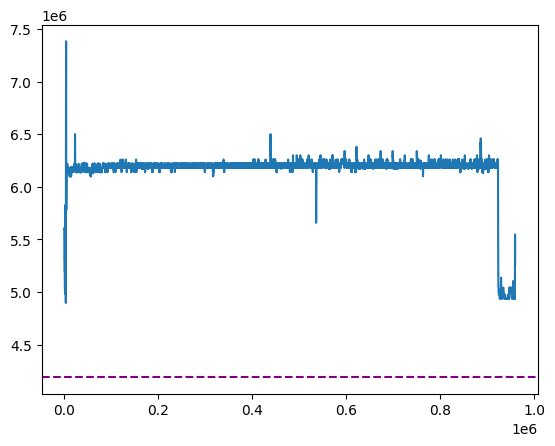

Model: vgg13


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 549996/549996 [00:09<00:00, 57974.64it/s]


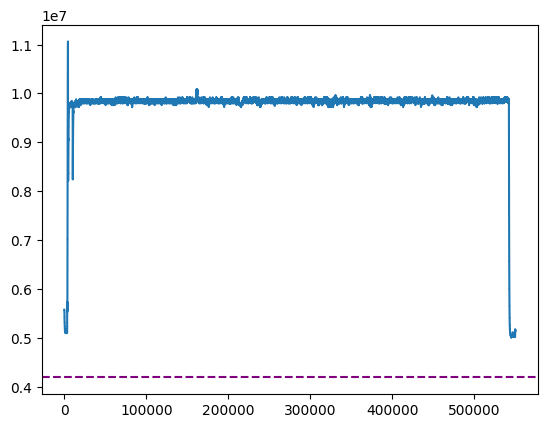

Model: resnet101


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2188549/2188549 [00:37<00:00, 58785.86it/s]


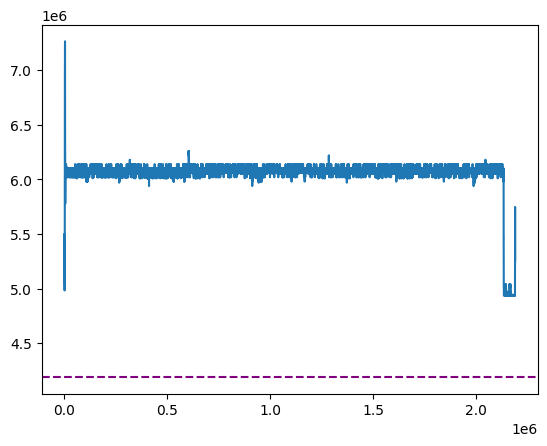

In [17]:
for model_path in DATA_PATH.iterdir():
    if model_path.is_dir():
        model_name = model_path.stem
        print(f"Model: {model_name}")
        with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
            data = fp.readlines()
        power_data = parse_power_log(data)
        plt.plot([power for (_, power) in power_data])
        plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
        plt.show()